In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import os

# Data Preprocessing

Stationarity Transformation Codes


In [3]:
def transxf(x, tcode):
    """
    Python implementation of the transxf function from prepare_missing.m
    """
    small = 1e-6
    n = len(x)
    y = np.full(n, np.nan)
    
    if tcode == 1: # Level
        y = x.values
    elif tcode == 2: # First Difference
        y[1:] = x.diff().iloc[1:]
    elif tcode == 3: # Second Difference
        y[2:] = x.diff().diff().iloc[2:]
    elif tcode == 4: # Natural Log
        y = np.log(x.where(x > small))
    elif tcode == 5: # Delta Log
        y[1:] = np.log(x).diff().iloc[1:]
    elif tcode == 6: # Delta^2 Log
        y[2:] = np.log(x).diff().diff().iloc[2:]
    elif tcode == 7: # Delta Percentage Change
        y[2:] = x.pct_change().diff().iloc[2:]
    return y

In [4]:
def remove_outliers_matlab(df):
    """
    Python implementation of remove_outliers.m
    Outlier if |x - median| > 10 * IQR
    """
    df_clean = df.copy()
    for col in df.columns:
        series = df[col]
        median = series.median()
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        
        # Define bounds
        lower = median - 10 * iqr
        upper = median + 10 * iqr
        
        # Replace outliers with NaN
        df_clean.loc[(series < lower) | (series > upper), col] = np.nan
    return df_clean

In [5]:
df_raw = pd.read_csv('CPI_Data/FRED-MD.csv')
df_raw

,sasdate,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,...,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx
0,Transform:,5.000,5.0,5.000,5.000000e+00,5.00000,5.0000,5.0000,5.0000,5.0000,...,6.000,6.000,6.00,6.00,6.00,2.0,6.00,6.00,6.0000,1.0000
1,1/1/1959,2583.560,2426.0,15.188,2.766768e+05,17689.23968,21.9998,23.6312,22.5507,32.1377,...,18.294,10.152,2.13,2.45,2.04,NaN,6476.00,12298.00,84.2043,NaN
2,2/1/1959,2593.596,2434.8,15.346,2.787140e+05,17819.01912,22.4306,23.9501,22.7461,32.3734,...,18.302,10.167,2.14,2.46,2.05,NaN,6476.00,12298.00,83.5280,NaN
3,3/1/1959,2610.396,2452.7,15.491,2.777753e+05,17967.91336,22.7538,24.0951,22.8577,32.3734,...,18.289,10.185,2.15,2.45,2.07,NaN,6508.00,12349.00,81.6405,NaN
4,4/1/1959,2627.446,2470.0,15.435,2.833627e+05,17978.97983,23.2384,24.4431,23.1926,32.8841,...,18.300,10.221,2.16,2.47,2.08,NaN,6620.00,12484.00,81.8099,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
800,8/1/2025,20582.726,16638.6,124.869,1.562681e+06,731700.00000,101.5867,97.7621,97.7555,98.3075,...,120.335,133.220,32.58,37.49,29.08,58.2,547634.28,937137.80,5628.6726,15.7545
801,9/1/2025,20601.264,16651.2,125.007,1.551628e+06,732192.00000,101.7779,97.9941,97.9522,98.2327,...,121.218,133.452,32.71,37.61,29.21,55.1,542484.79,935729.08,5651.1169,15.6325
802,10/1/2025,20592.481,16646.0,125.390,1.554989e+06,731412.00000,101.5163,97.6578,97.5438,97.5637,...,120.897,133.832,32.81,37.69,29.34,53.6,540148.30,934485.63,5661.0021,18.0058
803,11/1/2025,20612.309,16667.0,125.769,NaN,735904.00000,101.9528,98.0290,97.9867,98.1242,...,121.119,134.138,32.98,37.88,29.49,51.0,538661.37,933603.64,5658.5233,19.3448


In [6]:
tcodes = df_raw.iloc[0, 1:].astype(int).to_dict()
tcodes

{'RPI': 5,
 'W875RX1': 5,
 'DPCERA3M086SBEA': 5,
 'CMRMTSPLx': 5,
 'RETAILx': 5,
 'INDPRO': 5,
 'IPFPNSS': 5,
 'IPFINAL': 5,
 'IPCONGD': 5,
 'IPDCONGD': 5,
 'IPNCONGD': 5,
 'IPBUSEQ': 5,
 'IPMAT': 5,
 'IPDMAT': 5,
 'IPNMAT': 5,
 'IPMANSICS': 5,
 'IPB51222S': 5,
 'IPFUELS': 5,
 'CUMFNS': 2,
 'HWI': 2,
 'HWIURATIO': 2,
 'CLF16OV': 5,
 'CE16OV': 5,
 'UNRATE': 2,
 'UEMPMEAN': 2,
 'UEMPLT5': 5,
 'UEMP5TO14': 5,
 'UEMP15OV': 5,
 'UEMP15T26': 5,
 'UEMP27OV': 5,
 'CLAIMSx': 5,
 'PAYEMS': 5,
 'USGOOD': 5,
 'CES1021000001': 5,
 'USCONS': 5,
 'MANEMP': 5,
 'DMANEMP': 5,
 'NDMANEMP': 5,
 'SRVPRD': 5,
 'USTPU': 5,
 'USWTRADE': 5,
 'USTRADE': 5,
 'USFIRE': 5,
 'USGOVT': 5,
 'CES0600000007': 1,
 'AWOTMAN': 2,
 'AWHMAN': 1,
 'HOUST': 4,
 'HOUSTNE': 4,
 'HOUSTMW': 4,
 'HOUSTS': 4,
 'HOUSTW': 4,
 'PERMIT': 4,
 'PERMITNE': 4,
 'PERMITMW': 4,
 'PERMITS': 4,
 'PERMITW': 4,
 'ACOGNO': 5,
 'AMDMNOx': 5,
 'ANDENOx': 5,
 'AMDMUOx': 5,
 'BUSINVx': 5,
 'ISRATIOx': 2,
 'M1SL': 6,
 'M2SL': 6,
 'M2REAL': 5,
 'BOGMB

In [7]:
data = df_raw.iloc[1:].copy()
data

,sasdate,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,...,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx
1,1/1/1959,2583.560,2426.0,15.188,2.766768e+05,17689.23968,21.9998,23.6312,22.5507,32.1377,...,18.294,10.152,2.13,2.45,2.04,NaN,6476.00,12298.00,84.2043,NaN
2,2/1/1959,2593.596,2434.8,15.346,2.787140e+05,17819.01912,22.4306,23.9501,22.7461,32.3734,...,18.302,10.167,2.14,2.46,2.05,NaN,6476.00,12298.00,83.5280,NaN
3,3/1/1959,2610.396,2452.7,15.491,2.777753e+05,17967.91336,22.7538,24.0951,22.8577,32.3734,...,18.289,10.185,2.15,2.45,2.07,NaN,6508.00,12349.00,81.6405,NaN
4,4/1/1959,2627.446,2470.0,15.435,2.833627e+05,17978.97983,23.2384,24.4431,23.1926,32.8841,...,18.300,10.221,2.16,2.47,2.08,NaN,6620.00,12484.00,81.8099,NaN
5,5/1/1959,2642.720,2486.4,15.622,2.853072e+05,18119.82573,23.5885,24.6460,23.4159,33.0413,...,18.280,10.238,2.17,2.48,2.08,95.3,6753.00,12646.00,80.7315,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
800,8/1/2025,20582.726,16638.6,124.869,1.562681e+06,731700.00000,101.5867,97.7621,97.7555,98.3075,...,120.335,133.220,32.58,37.49,29.08,58.2,547634.28,937137.80,5628.6726,15.7545
801,9/1/2025,20601.264,16651.2,125.007,1.551628e+06,732192.00000,101.7779,97.9941,97.9522,98.2327,...,121.218,133.452,32.71,37.61,29.21,55.1,542484.79,935729.08,5651.1169,15.6325
802,10/1/2025,20592.481,16646.0,125.390,1.554989e+06,731412.00000,101.5163,97.6578,97.5438,97.5637,...,120.897,133.832,32.81,37.69,29.34,53.6,540148.30,934485.63,5661.0021,18.0058
803,11/1/2025,20612.309,16667.0,125.769,NaN,735904.00000,101.9528,98.0290,97.9867,98.1242,...,121.119,134.138,32.98,37.88,29.49,51.0,538661.37,933603.64,5658.5233,19.3448


In [8]:
data['sasdate'] = pd.to_datetime(data['sasdate'])
data.set_index('sasdate', inplace=True)
data

,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,IPDCONGD,...,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx
sasdate,,,,,,,,,,,,,,,,,,,,,
1959-01-01,2583.560,2426.0,15.188,2.766768e+05,17689.23968,21.9998,23.6312,22.5507,32.1377,19.7514,...,18.294,10.152,2.13,2.45,2.04,NaN,6476.00,12298.00,84.2043,NaN
1959-02-01,2593.596,2434.8,15.346,2.787140e+05,17819.01912,22.4306,23.9501,22.7461,32.3734,19.8551,...,18.302,10.167,2.14,2.46,2.05,NaN,6476.00,12298.00,83.5280,NaN
1959-03-01,2610.396,2452.7,15.491,2.777753e+05,17967.91336,22.7538,24.0951,22.8577,32.3734,20.2439,...,18.289,10.185,2.15,2.45,2.07,NaN,6508.00,12349.00,81.6405,NaN
1959-04-01,2627.446,2470.0,15.435,2.833627e+05,17978.97983,23.2384,24.4431,23.1926,32.8841,20.3735,...,18.300,10.221,2.16,2.47,2.08,NaN,6620.00,12484.00,81.8099,NaN
1959-05-01,2642.720,2486.4,15.622,2.853072e+05,18119.82573,23.5885,24.6460,23.4159,33.0413,20.7882,...,18.280,10.238,2.17,2.48,2.08,95.3,6753.00,12646.00,80.7315,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-01,20582.726,16638.6,124.869,1.562681e+06,731700.00000,101.5867,97.7621,97.7555,98.3075,99.3199,...,120.335,133.220,32.58,37.49,29.08,58.2,547634.28,937137.80,5628.6726,15.7545
2025-09-01,20601.264,16651.2,125.007,1.551628e+06,732192.00000,101.7779,97.9941,97.9522,98.2327,98.3147,...,121.218,133.452,32.71,37.61,29.21,55.1,542484.79,935729.08,5651.1169,15.6325
2025-10-01,20592.481,16646.0,125.390,1.554989e+06,731412.00000,101.5163,97.6578,97.5438,97.5637,95.1809,...,120.897,133.832,32.81,37.69,29.34,53.6,540148.30,934485.63,5661.0021,18.0058


In [9]:
data = data.apply(pd.to_numeric, errors='coerce')
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 804 entries, 1959-01-01 to 2025-12-01
Columns: 126 entries, RPI to VIXCLSx
dtypes: float64(115), int64(11)
memory usage: 797.7 KB


In [10]:
transformed_columns = []

for col, code in tcodes.items():
    transformed_series = transxf(data[col], code)
    
    transformed_columns.append(pd.Series(transformed_series, index=data.index, name=col))

# Concatenate all columns 
df_transformed = pd.concat(transformed_columns, axis=1)

# outlier removal
df_transformed = remove_outliers_matlab(df_transformed)

In [11]:
#Handling Missing Values 

#Interpolate internal missing values linearly 
df_filled = df_transformed.interpolate(method='linear', limit_direction='both', axis=0)

# Forward fill and Backward fill any remaining edge NaNs
df_filled = df_filled.ffill().bfill()

In [12]:
df_filled[['CPIAUCSL']]

,CPIAUCSL
sasdate,
1959-01-01,-0.000690
1959-02-01,-0.000690
1959-03-01,-0.000690
1959-04-01,0.001380
1959-05-01,0.001723
...,...
2025-08-01,0.001853
2025-09-01,-0.000717
2025-10-01,-0.000717


In [13]:
#Create 4 lags for all variables (508 predictors)

lag_list = []
# Create 4 lags for all 122 variables (The 'Data-Rich' environment)
for i in range(1, 5):
    lag_list.append(df_filled.shift(i).add_suffix(f'_lag{i}'))

# Combine lags into a single predictor matrix (508 features total)
X = pd.concat(lag_list, axis=1)
X

,RPI_lag1,W875RX1_lag1,DPCERA3M086SBEA_lag1,CMRMTSPLx_lag1,RETAILx_lag1,INDPRO_lag1,IPFPNSS_lag1,IPFINAL_lag1,IPCONGD_lag1,IPDCONGD_lag1,...,DNDGRG3M086SBEA_lag4,DSERRG3M086SBEA_lag4,CES0600000008_lag4,CES2000000008_lag4,CES3000000008_lag4,UMCSENTx_lag4,DTCOLNVHFNM_lag4,DTCTHFNM_lag4,INVEST_lag4,VIXCLSx_lag4
sasdate,,,,,,,,,,,,,,,,,,,,,
1959-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1959-02-01,0.003877,0.003621,0.010349,0.007336,0.007310,0.019393,0.013405,0.008628,0.007307,0.005237,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1959-03-01,0.003877,0.003621,0.010349,0.007336,0.007310,0.019393,0.013405,0.008628,0.007307,0.005237,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1959-04-01,0.006457,0.007325,0.009404,-0.003374,0.008321,0.014306,0.006036,0.004894,0.000000,0.019393,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1959-05-01,0.006510,0.007029,-0.003622,0.019915,0.000616,0.021074,0.014339,0.014545,0.015652,0.006382,...,-0.001148,0.000292,-0.000022,-0.008147,0.004819,0.6,0.004929,0.004138,-0.014792,19.5715
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-01,0.003071,0.003335,0.004920,0.005833,0.006471,0.004086,0.004728,0.007699,0.005888,-0.001624,...,0.006353,-0.000560,-0.005614,0.000527,-0.011814,-4.8,0.002165,0.003434,0.004366,32.5116
2025-09-01,0.001212,-0.000018,0.002919,-0.002092,0.005445,-0.003020,-0.003644,-0.006181,-0.006385,0.003448,...,0.001846,0.000421,0.001858,-0.001097,0.006591,0.0,-0.002830,-0.003157,-0.007588,20.3620
2025-10-01,0.000900,0.000757,0.001105,-0.007098,0.000672,0.001880,0.002370,0.002010,-0.000761,-0.010172,...,0.002548,0.000078,-0.000008,0.000796,-0.000701,8.5,-0.000590,-0.000334,0.000459,18.3246


In [14]:
y_base = df_filled['CPIAUCSL'] 

In [13]:
X.shape, y_base.shape

((804, 504), (804,))

In [15]:
def get_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mad = np.median(np.abs(y_true - y_pred)) # Median Absolute Deviation
    return rmse, mae, mad

In [16]:
class AdaptiveLasso:
    def __init__(self, cv=5):
        self.cv = cv
        self.scaler = StandardScaler()
    def fit(self, X, y):
        X_std = self.scaler.fit_transform(X)
        first_stage = LassoCV(cv=self.cv, max_iter=10000, tol=1e-3).fit(X_std, y)
        weights = 1.0 / (np.abs(first_stage.coef_) + 1e-5)
        X_weighted = X_std / weights
        second_stage = LassoCV(cv=self.cv, max_iter=10000, tol=1e-3).fit(X_weighted, y)
        self.coef_ = second_stage.coef_ / weights
        self.intercept_ = second_stage.intercept_
        return self
    def predict(self, X):
        X_std = self.scaler.transform(X)
        return np.dot(X_std, self.coef_) + self.intercept_

### Model Training & Evaluation

In [17]:
window_size = 240
test_size = 60
horizons = range(1, 13)
rw_rmse_by_h = {}

Random Walk

In [18]:
backtest_rw = []
forecast_rw = []

for h in horizons:
    y_target = y_base.shift(-h)
    data_subset = pd.concat([y_target, X], axis=1).dropna()
    y_clean, X_clean = data_subset.iloc[:, 0], data_subset.iloc[:, 1:]
    test_indices = range(len(X_clean) - test_size, len(X_clean))

    for t in test_indices:
        # RW forecast is simply the value at time t
        rw_f = y_base.loc[X_clean.index[t]] 
        backtest_rw.append({'Horizon': h, 'Actual': y_clean.iloc[t], 'Pred': rw_f})

    # Future Forecast (2026)
    last_val = y_base.iloc[-1]
    forecast_rw.append({'Month': X.index[-1] + pd.DateOffset(months=h), 
                        'Forecast': (np.exp(last_val * 12) - 1) * 100})

# Summary Table
df_rw_backtest = pd.DataFrame(backtest_rw)
df_rw_forecast = pd.DataFrame(forecast_rw)
print(f"{'H':<3} | {'RMSE':<8} | {'MAE':<8} | {'MAD':<8}")
for h in [1, 3, 6, 12]:
    sub = df_rw_backtest[df_rw_backtest['Horizon'] == h]
    rmse, mae, mad = get_metrics(sub['Actual'], sub['Pred'])
    rw_rmse_by_h[h] = rmse # Save for later
    print(f"{h:<3} | {rmse:.5f} | {mae:.5f} | {mad:.5f}")

df_rw_backtest.to_csv('backtest_rw.csv')
df_rw_forecast.to_csv('forecast_rw.csv')
print('Files saved')

H   | RMSE     | MAE      | MAD     
1   | 0.00459 | 0.00309 | 0.00218
3   | 0.00369 | 0.00270 | 0.00201
6   | 0.00454 | 0.00319 | 0.00261
12  | 0.00415 | 0.00325 | 0.00260
Files saved


Ridge Regression

In [22]:
backtest_ridge = []
forecast_ridge = []

for h in horizons:
    print(f"Processing Horizon h={h}...")
    y_target = y_base.shift(-h)
    data_subset = pd.concat([y_target, X], axis=1).dropna()
    y_clean, X_clean = data_subset.iloc[:, 0], data_subset.iloc[:, 1:]
    test_indices = range(len(X_clean) - test_size, len(X_clean))

    for t in test_indices:
        train_start = max(0, t - window_size)
        model = RidgeCV(alphas=np.logspace(-3, 3, 20)).fit(X_clean.iloc[train_start:t], y_clean.iloc[train_start:t])
        pred = model.predict(X_clean.iloc[[t]])[0]
        backtest_ridge.append({'Horizon': h, 'Actual': y_clean.iloc[t], 'Pred': pred})

    # Future Forecast (2026)
    final_model = RidgeCV().fit(X_clean.iloc[-window_size:], y_clean.iloc[-window_size:])
    future_raw = final_model.predict(X.iloc[[-1]])[0]
    forecast_ridge.append({'Month': X.index[-1] + pd.DateOffset(months=h), 
                           'Forecast': (np.exp(future_raw * 12) - 1) * 100})



Processing Horizon h=1...
Processing Horizon h=2...
Processing Horizon h=3...
Processing Horizon h=4...
Processing Horizon h=5...
Processing Horizon h=6...
Processing Horizon h=7...
Processing Horizon h=8...
Processing Horizon h=9...
Processing Horizon h=10...
Processing Horizon h=11...
Processing Horizon h=12...


In [23]:
# Summary Table
df_rr_backtest = pd.DataFrame(backtest_ridge)
df_rr_forecast = pd.DataFrame(forecast_ridge)

print(f"{'H':<3} | {'RMSE':<8} | {'MAE':<8} | {'MAD':<8}  | {'Rel. RW'}")
for h in [1, 3, 6, 12]:
    sub = df_rr_backtest[df_rr_backtest['Horizon'] == h]
    rmse, mae, mad = get_metrics(sub['Actual'], sub['Pred'])
    print(f"{h:<3} | {rmse:.5f} | {mae:.5f} | {mad:.5f} |  {rmse/rw_rmse_by_h[h]:.3f}")

df_rr_backtest.to_csv('backtest_rr.csv')
df_rr_forecast.to_csv('forecast_rr.csv')
print('Files saved')

H   | RMSE     | MAE      | MAD       | Rel. RW
1   | 0.00302 | 0.00213 | 0.00159 |  0.657
3   | 0.00294 | 0.00215 | 0.00152 |  0.797
6   | 0.00308 | 0.00222 | 0.00161 |  0.678
12  | 0.00324 | 0.00233 | 0.00157 |  0.782
Files saved


Adaptive lasso Training

In [25]:
backtest_al = []
forecast_al = []

for h in horizons:
    print(f"Processing Horizon h={h}...")
    y_target = y_base.shift(-h)
    data_subset = pd.concat([y_target, X], axis=1).dropna()
    y_clean, X_clean = data_subset.iloc[:, 0], data_subset.iloc[:, 1:]
    test_indices = range(len(X_clean) - test_size, len(X_clean))

    for t in test_indices:
        train_start = max(0, t - window_size)
        model = AdaptiveLasso().fit(X_clean.iloc[train_start:t], y_clean.iloc[train_start:t])
        pred = model.predict(X_clean.iloc[[t]])[0]
        backtest_al.append({'Horizon': h, 'Actual': y_clean.iloc[t], 'Pred': pred})

    # Future Forecast (2026)
    final_model = AdaptiveLasso().fit(X_clean.iloc[-window_size:], y_clean.iloc[-window_size:])
    future_raw = final_model.predict(X.iloc[[-1]])[0]
    forecast_al.append({'Month': X.index[-1] + pd.DateOffset(months=h), 
                        'Forecast': (np.exp(future_raw * 12) - 1) * 100})

# Summary Table
df_al_backtest = pd.DataFrame(backtest_al)
df_al_forecast = pd.DataFrame(forecast_al)

print(f"{'H':<3} | {'RMSE':<8} | {'MAE':<8} | {'MAD':<8}  | {'Rel. RW'}")
for h in [1, 3, 6, 12]:
    sub = df_al_backtest[df_al_backtest['Horizon'] == h]
    rmse, mae, mad = get_metrics(sub['Actual'], sub['Pred'])
    print(f"{h:<3} | {rmse:.5f} | {mae:.5f} | {mad:.5f} |  {rmse/rw_rmse_by_h[h]:.3f}")

df_al_backtest.to_csv('backtest_al.csv')
df_al_forecast.to_csv('forecast_al.csv')
print('Files saved')

Processing Horizon h=1...
Processing Horizon h=2...
Processing Horizon h=3...
Processing Horizon h=4...
Processing Horizon h=5...
Processing Horizon h=6...
Processing Horizon h=7...
Processing Horizon h=8...
Processing Horizon h=9...
Processing Horizon h=10...
Processing Horizon h=11...
Processing Horizon h=12...
H   | RMSE     | MAE      | MAD       | Rel. RW
1   | 0.00267 | 0.00182 | 0.00126 |  0.581
3   | 0.00288 | 0.00203 | 0.00136 |  0.780
6   | 0.00287 | 0.00203 | 0.00136 |  0.632
12  | 0.00303 | 0.00220 | 0.00154 |  0.731
Files saved


Random Forest Training

In [ ]:

# Hyperparameter tuning for random forest
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_features': ['sqrt', 0.3, 0.5],
    'max_depth': [4, 6, 8, None],
    'min_samples_leaf': [2, 5, 10]
}

# a representative baseline horizon (h=1)
tuning_h = 1
y_target_tune = y_base.shift(-tuning_h)
tuning_subset = pd.concat([y_target_tune, X], axis=1).dropna()
y_tune_clean, X_tune_clean = tuning_subset.iloc[:, 0], tuning_subset.iloc[:, 1:]

# Isolate historical data up to the start of the validation backtest block
test_indices_tune = range(len(X_tune_clean) - test_size, len(X_tune_clean))
X_tuning_matrix = X_tune_clean.iloc[:test_indices_tune[0]]
y_tuning_matrix = y_tune_clean.iloc[:test_indices_tune[0]]

# Enforce a forward-chaining cross-validation structure
tscv = TimeSeriesSplit(n_splits=5)
rf_base = RandomForestRegressor(n_jobs=-1, random_state=42)

# Execute Grid Search once globally
global_grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)
global_grid_search.fit(X_tuning_matrix, y_tuning_matrix)

best_params = global_grid_search.best_params_

print(f"--> Best Parameters: {best_params}")


--> Best Parameters: {'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 200}


In [24]:
backtest_rf = []
forecast_rf = []

for h in horizons:
    print(f"Processing Horizon h={h}...")
    y_target = y_base.shift(-h)
    data_subset = pd.concat([y_target, X], axis=1).dropna()
    y_clean, X_clean = data_subset.iloc[:, 0], data_subset.iloc[:, 1:]
    test_indices = range(len(X_clean) - test_size, len(X_clean))

    # Monthly Rolling Backtest 
    for t in test_indices:
        train_start = max(0, t - window_size)
        
        # Instantiate model using the optimal global parameters discovered in Stage 1
        model = RandomForestRegressor(max_depth=4,max_features='sqrt',min_samples_leaf=10,n_estimators=200, n_jobs=-1, random_state=42)
        model.fit(X_clean.iloc[train_start:t], y_clean.iloc[train_start:t])
        
        pred = model.predict(X_clean.iloc[[t]])[0]
        backtest_rf.append({'Horizon': h, 'Actual': y_clean.iloc[t], 'Pred': pred})

    # Future Forecast 
    model.fit(X_clean.iloc[-window_size:], y_clean.iloc[-window_size:])
    
    future_raw = model.predict(X.iloc[[-1]])[0]
    forecast_rf.append({
        'Month': X.index[-1] + pd.DateOffset(months=h), 
        'Forecast': (np.exp(future_raw * 12) - 1) * 100
    })

# Metric Summaries
df_rf_backtest = pd.DataFrame(backtest_rf)
df_rf_forecast = pd.DataFrame(forecast_rf)

print(f"{'H':<3} | {'RMSE':<8} | {'MAE':<8} | {'MAD':<8}  | {'Rel. RW'}")
for h in [1, 3, 6, 12]:
    if h in horizons:
        sub = df_rf_backtest[df_rf_backtest['Horizon'] == h]
        rmse, mae, mad = get_metrics(sub['Actual'], sub['Pred'])
        print(f"{h:<3} | {rmse:.5f} | {mae:.5f} | {mad:.5f} |  {rmse/rw_rmse_by_h[h]:.3f}")


df_rf_backtest.to_csv('backtest_rf.csv', index=False)
df_rf_forecast.to_csv('forecast_rf.csv', index=False) 


Processing Horizon h=1...
Processing Horizon h=2...
Processing Horizon h=3...
Processing Horizon h=4...
Processing Horizon h=5...
Processing Horizon h=6...
Processing Horizon h=7...
Processing Horizon h=8...
Processing Horizon h=9...
Processing Horizon h=10...
Processing Horizon h=11...
Processing Horizon h=12...
H   | RMSE     | MAE      | MAD       | Rel. RW
1   | 0.00281 | 0.00197 | 0.00154 |  0.612
3   | 0.00286 | 0.00201 | 0.00140 |  0.773
6   | 0.00291 | 0.00207 | 0.00151 |  0.640
12  | 0.00279 | 0.00196 | 0.00148 |  0.673


In [26]:
#Importing backtest results
df_rw_backtest = pd.read_csv("backtest_rw.csv")
df_al_backtest = pd.read_csv("backtest_al.csv")
df_rr_backtest = pd.read_csv("backtest_rr.csv")
df_rf_backtest = pd.read_csv("backtest_rf.csv")

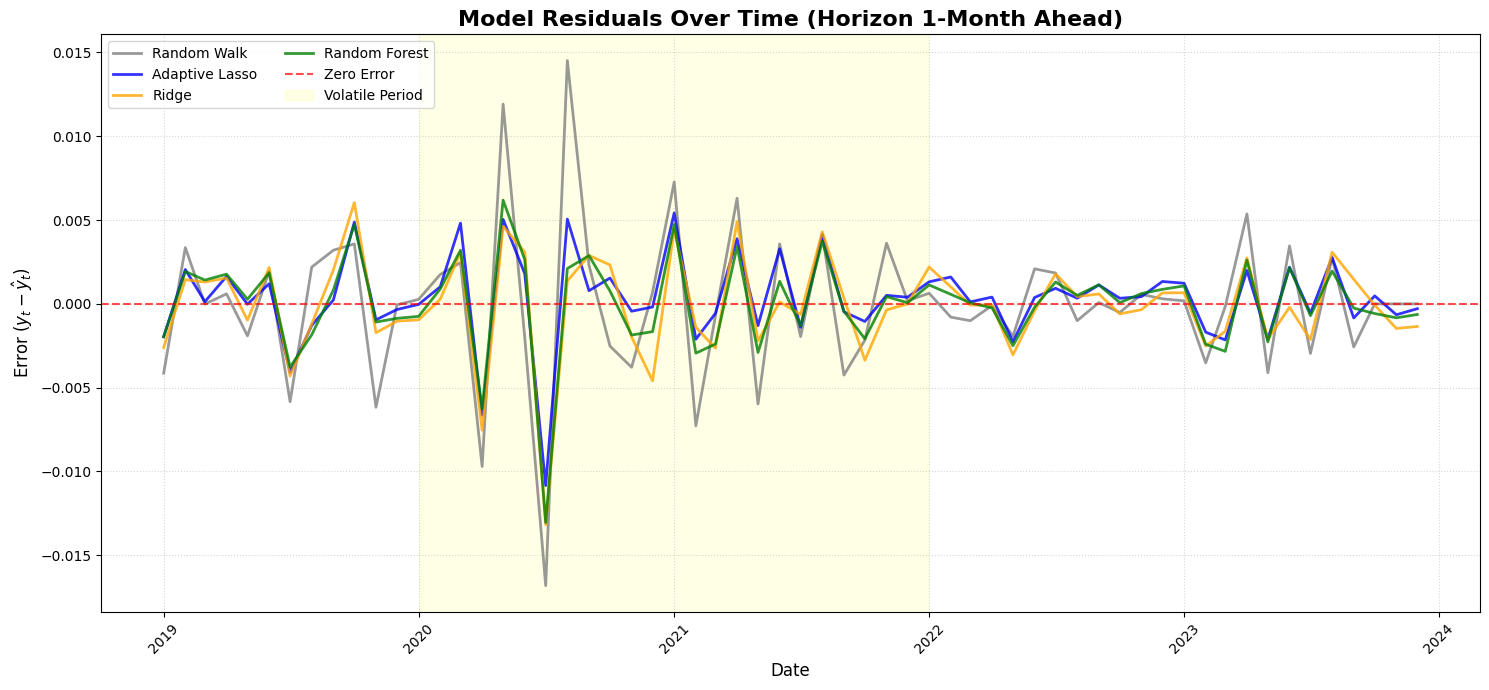

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Filter Horizon 1
h = 1 
models = {
    'Random Walk': df_rw_backtest[df_rw_backtest['Horizon'] == h].copy(),
    'Adaptive Lasso': df_al_backtest[df_al_backtest['Horizon'] == h].copy(),
    'Ridge': df_rr_backtest[df_rr_backtest['Horizon'] == h].copy(),
    'Random Forest': df_rf_backtest[df_rf_backtest['Horizon'] == h].copy()
}

# Add Dates 
date_range = pd.date_range(start='2019-01-01', periods=60, freq='MS')

for name, df in models.items():
    df['Date'] = date_range
    df['Residual'] = df['Actual'] - df['Pred']

#Residual Plot
plt.figure(figsize=(15, 7))

colors = {'Random Walk': 'gray', 'Adaptive Lasso': 'blue', 'Ridge': 'orange', 'Random Forest': 'green'}

for name, df in models.items():
    plt.plot(df['Date'], df['Residual'], label=name, color=colors[name], linewidth=2, alpha=0.8)

#zero line
plt.axhline(0, color='red', linestyle='--', alpha=0.7, label='Zero Error')

# Highlight Post-Pandemic Inflation Spike
plt.axvspan('2020-01-01', '2021-12-31', color='yellow', alpha=0.1, label='Volatile Period')

plt.title(f'Model Residuals Over Time (Horizon {h}-Month Ahead)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Error ($y_t - \hat{y}_t$)', fontsize=12)
plt.legend(loc='upper left', ncol=2)
plt.grid(True, which='both', linestyle=':', alpha=0.5)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

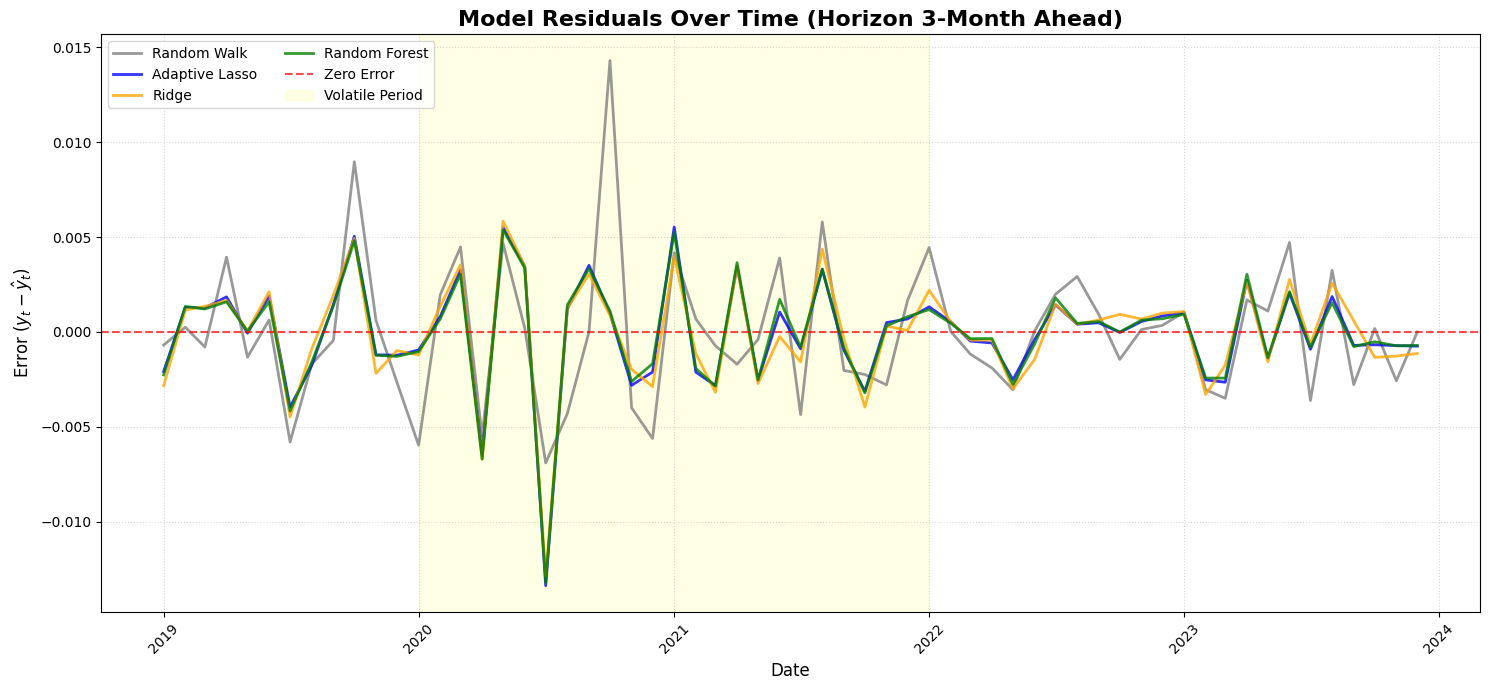

In [28]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

h = 3 
models = {
    'Random Walk': df_rw_backtest[df_rw_backtest['Horizon'] == h].copy(),
    'Adaptive Lasso': df_al_backtest[df_al_backtest['Horizon'] == h].copy(),
    'Ridge': df_rr_backtest[df_rr_backtest['Horizon'] == h].copy(),
    'Random Forest': df_rf_backtest[df_rf_backtest['Horizon'] == h].copy()
}

date_range = pd.date_range(start='2019-01-01', periods=60, freq='MS')

for name, df in models.items():
    df['Date'] = date_range
    df['Residual'] = df['Actual'] - df['Pred']


plt.figure(figsize=(15, 7))

colors = {'Random Walk': 'gray', 'Adaptive Lasso': 'blue', 'Ridge': 'orange', 'Random Forest': 'green'}

for name, df in models.items():
    plt.plot(df['Date'], df['Residual'], label=name, color=colors[name], linewidth=2, alpha=0.8)


plt.axhline(0, color='red', linestyle='--', alpha=0.7, label='Zero Error')


plt.axvspan('2020-01-01', '2021-12-31', color='yellow', alpha=0.1, label='Volatile Period')

plt.title(f'Model Residuals Over Time (Horizon {h}-Month Ahead)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Error ($y_t - \hat{y}_t$)', fontsize=12)
plt.legend(loc='upper left', ncol=2)
plt.grid(True, which='both', linestyle=':', alpha=0.5)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

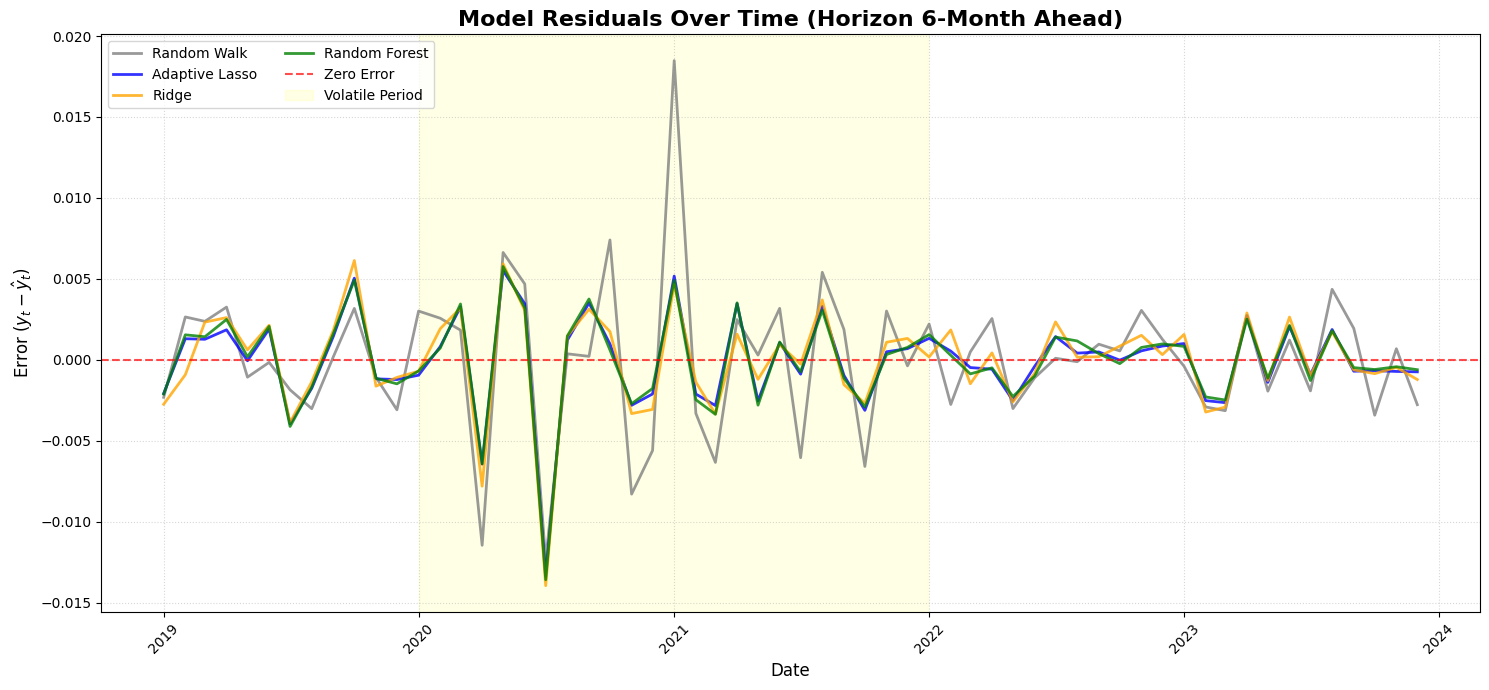

In [29]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

h = 6 
models = {
    'Random Walk': df_rw_backtest[df_rw_backtest['Horizon'] == h].copy(),
    'Adaptive Lasso': df_al_backtest[df_al_backtest['Horizon'] == h].copy(),
    'Ridge': df_rr_backtest[df_rr_backtest['Horizon'] == h].copy(),
    'Random Forest': df_rf_backtest[df_rf_backtest['Horizon'] == h].copy()
}


date_range = pd.date_range(start='2019-01-01', periods=60, freq='MS')

for name, df in models.items():
    df['Date'] = date_range
    df['Residual'] = df['Actual'] - df['Pred']


plt.figure(figsize=(15, 7))

colors = {'Random Walk': 'gray', 'Adaptive Lasso': 'blue', 'Ridge': 'orange', 'Random Forest': 'green'}

for name, df in models.items():
    plt.plot(df['Date'], df['Residual'], label=name, color=colors[name], linewidth=2, alpha=0.8)


plt.axhline(0, color='red', linestyle='--', alpha=0.7, label='Zero Error')

plt.axvspan('2020-01-01', '2021-12-31', color='yellow', alpha=0.1, label='Volatile Period')

plt.title(f'Model Residuals Over Time (Horizon {h}-Month Ahead)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Error ($y_t - \hat{y}_t$)', fontsize=12)
plt.legend(loc='upper left', ncol=2)
plt.grid(True, which='both', linestyle=':', alpha=0.5)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

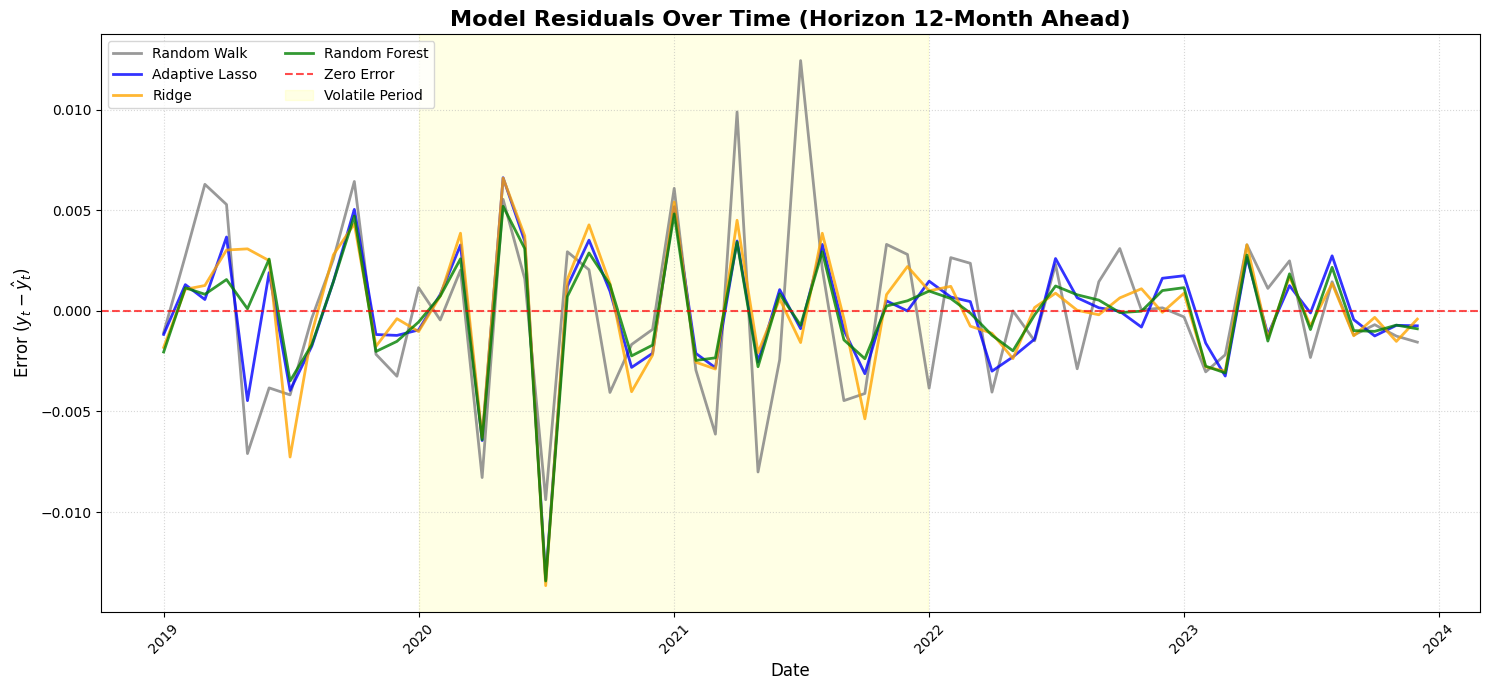

In [30]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

h = 12
models = {
    'Random Walk': df_rw_backtest[df_rw_backtest['Horizon'] == h].copy(),
    'Adaptive Lasso': df_al_backtest[df_al_backtest['Horizon'] == h].copy(),
    'Ridge': df_rr_backtest[df_rr_backtest['Horizon'] == h].copy(),
    'Random Forest': df_rf_backtest[df_rf_backtest['Horizon'] == h].copy()
}

date_range = pd.date_range(start='2019-01-01', periods=60, freq='MS')

for name, df in models.items():
    df['Date'] = date_range
    df['Residual'] = df['Actual'] - df['Pred']


plt.figure(figsize=(15, 7))

colors = {'Random Walk': 'gray', 'Adaptive Lasso': 'blue', 'Ridge': 'orange', 'Random Forest': 'green'}

for name, df in models.items():
    plt.plot(df['Date'], df['Residual'], label=name, color=colors[name], linewidth=2, alpha=0.8)

plt.axhline(0, color='red', linestyle='--', alpha=0.7, label='Zero Error')

plt.axvspan('2020-01-01', '2021-12-31', color='yellow', alpha=0.1, label='Volatile Period')

plt.title(f'Model Residuals Over Time (Horizon {h}-Month Ahead)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Error ($y_t - \hat{y}_t$)', fontsize=12)
plt.legend(loc='upper left', ncol=2)
plt.grid(True, which='both', linestyle=':', alpha=0.5)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Forecast Plot

In [ ]:
df_al = pd.read_csv('forecast_al.csv')
df_rf = pd.read_csv('forecast_rf.csv')
df_rr = pd.read_csv('forecast_rr.csv')
df_rw = pd.read_csv('forecast_rw.csv')

df_al['Date'] = pd.to_datetime(df_al['Month'], format='%Y-%m-%d')
df_rr['Date'] = pd.to_datetime(df_rr['Month'], format='%Y-%m-%d')
df_rw['Date'] = pd.to_datetime(df_rw['Month'], format='%Y-%m-%d')
df_rf['Date'] = pd.to_datetime(df_rf['Month'], format='%d/%m/%Y')

df_al = df_al.set_index('Date')
df_rf = df_rf.set_index('Date')
df_rr = df_rr.set_index('Date')
df_rw = df_rw.set_index('Date')

forecast_df = pd.DataFrame({
    'AL': df_al['Forecast'],
    'RF': df_rf['Forecast'],
    'RR': df_rr['Forecast'],
    'RW': df_rw['Forecast']
})

forecast_df = forecast_df.sort_index()
print(forecast_df)

                  AL        RF        RR        RW
Date                                              
2026-01-01  0.091576 -0.082331 -0.404754 -0.856916
2026-02-01  0.044762 -0.052114 -0.957425 -0.856916
2026-03-01  0.004743 -0.388227 -1.492792 -0.856916
2026-04-01  0.004743 -0.255602 -0.739053 -0.856916
2026-05-01  0.004743 -0.339180 -0.474731 -0.856916
2026-06-01  0.004743  0.311961  1.632913 -0.856916
2026-07-01  0.004743  0.157552  1.359057 -0.856916
2026-08-01  0.004743  0.182843  0.322668 -0.856916
2026-09-01  0.004743 -0.053893 -0.732628 -0.856916
2026-10-01  0.004743  0.215334 -0.226240 -0.856916
2026-11-01  0.004743 -0.032482 -0.384417 -0.856916
2026-12-01 -0.009241 -0.011333 -0.889009 -0.856916


In [21]:
weights_by_horizon = {
    1:  [0.3593, 0.3177, 0.3230], # Matched to h=1 metrics
    3:  [0.3421, 0.3352, 0.3227], # Matched to h=3 metrics
    6:  [0.3444, 0.3209, 0.3347], # Matched to h=6 metrics
    12: [0.3184, 0.2977, 0.3839]  # Matched to h=12 metrics
}

In [22]:
simple_ensemble = []
weighted_ensemble = []

# Map out each step from 1 to 12
for step, (idx, row) in enumerate(forecast_df.iterrows(), start=1):
    # Calculate simple mean of structural models
    s_ens = (row['RF'] + row['RR'] + row['AL']) / 3
    simple_ensemble.append(s_ens)
    
    # Select the optimal backtest weight set based on proximity to step
    if step == 1: h_key = 1
    elif step <= 4: h_key = 3
    elif step <= 9: h_key = 6
    else: h_key = 12
        
    w = weights_by_horizon[h_key]
    w_ens = (row['AL'] * w[0]) + (row['RR'] * w[1]) + (row['RF'] * w[2])
    weighted_ensemble.append(w_ens)

forecast_df['Simple_Ensemble'] = simple_ensemble
forecast_df['Weighted_Ensemble'] = weighted_ensemble

In [23]:
hist_df = pd.read_csv('merged_inflation_rates.csv',index_col=0)
hist_df['Date'] = pd.to_datetime(hist_df['Date'])
hist_df = hist_df.dropna(subset=['Standard']).set_index('Date')
hist_df

,Standard,Core,Supercore
Date,,,
2001-01-01,3.721205,2.565533,5.731523
2001-02-01,3.529412,2.787068,5.614035
2001-03-01,2.982456,2.611111,5.397301
2001-04-01,3.218256,2.662230,5.231689
2001-05-01,3.563084,2.545656,5.265772
...,...,...,...
2025-08-01,2.939220,3.112191,4.043143
2025-09-01,3.022700,3.025543,3.698376
2025-10-01,2.894975,2.834113,3.509693


In [25]:
history_cleaned = hist_df.loc['2020-01-01':'2025-12-01', ['Standard']].rename(columns={'Standard': 'Actual'})

# Bridging
last_date = history_cleaned.index[-1]
last_val = history_cleaned['Actual'].iloc[-1]

columns_to_project = ['AL', 'RF', 'RR', 'RW', 'Simple_Ensemble', 'Weighted_Ensemble']
scaled_forecasts = pd.DataFrame(index=forecast_df.index, columns=columns_to_project)

for col in columns_to_project:
    # add historical + forecast
    scaled_forecasts[col] = last_val + forecast_df[col].cumsum()

# Establish the Visual Bridge Row
bridge_row = pd.DataFrame([[last_val] * 6], index=[last_date], columns=columns_to_project)
clean_forecasts = pd.concat([bridge_row, scaled_forecasts])

# merge dataset
final_merged = history_cleaned.join(clean_forecasts, how='outer')

#final_merged.to_csv('final_inflation_12m_forecast.csv')
print(final_merged.loc['2025-11-01':].round(4))


            Actual      AL      RF      RR      RW  Simple_Ensemble  \
2025-11-01  2.7120     NaN     NaN     NaN     NaN              NaN   
2025-12-01  2.6533  2.6533  2.6533  2.6533  2.6533           2.6533   
2026-01-01     NaN  2.7449  2.5710  2.2486  1.7964           2.5215   
2026-02-01     NaN  2.7897  2.5189  1.2911  0.9395           2.1999   
2026-03-01     NaN  2.7944  2.1306 -0.2017  0.0826           1.5745   
2026-04-01     NaN  2.7991  1.8750 -0.9407 -0.7744           1.2445   
2026-05-01     NaN  2.8039  1.5359 -1.4154 -1.6313           0.9748   
2026-06-01     NaN  2.8086  1.8478  0.2175 -2.4882           1.6246   
2026-07-01     NaN  2.8134  2.0054  1.5765 -3.3451           2.1318   
2026-08-01     NaN  2.8181  2.1882  1.8992 -4.2020           2.3018   
2026-09-01     NaN  2.8228  2.1343  1.1666 -5.0589           2.0412   
2026-10-01     NaN  2.8276  2.3497  0.9403 -5.9159           2.0392   
2026-11-01     NaN  2.8323  2.3172  0.5559 -6.7728           1.9018   
2026-1

In [27]:
final_merged.to_csv('final_inflation_12m_forecast.csv')

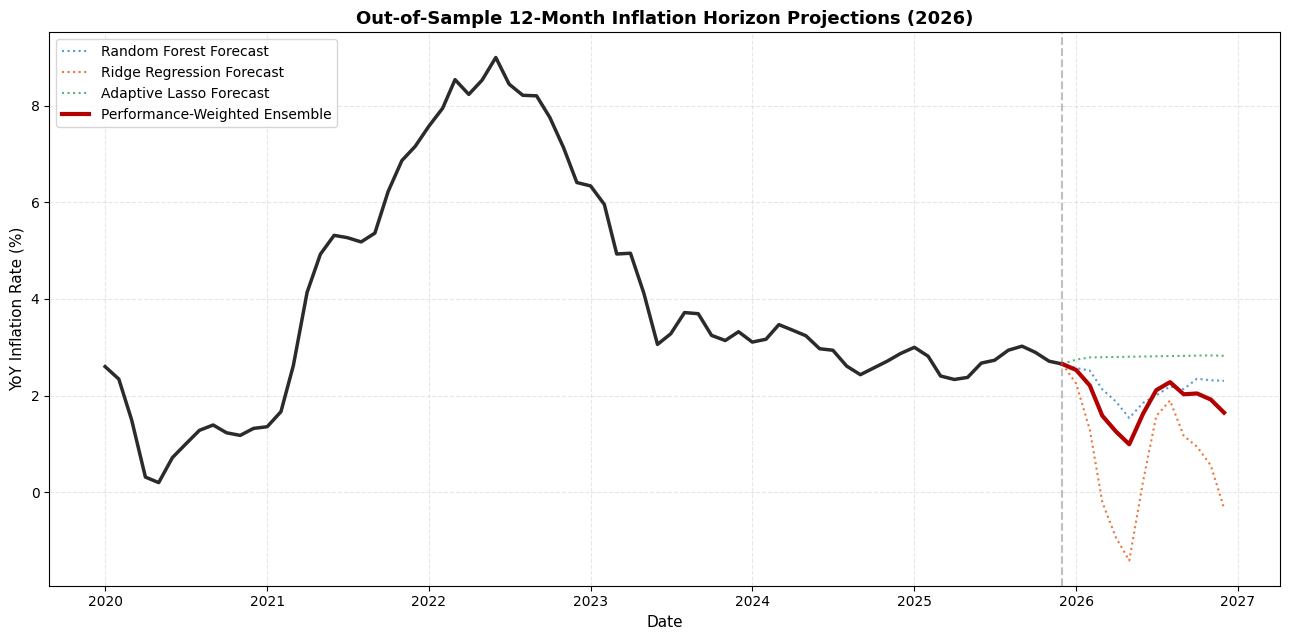

In [28]:
import matplotlib.pyplot as plt

df_plot = pd.read_csv('final_inflation_12m_forecast.csv', index_col=0, parse_dates=True)

plt.figure(figsize=(13, 6.5))
# Plot historical line
plt.plot(final_merged.index, final_merged['Actual'], color='#2b2b2b', linewidth=2.5)

# Plot forecast lines originating from the bridge point
forecast_range = df_plot.loc['2025-12-01':].index
plt.plot(forecast_range, df_plot.loc['2025-12-01':, 'RF'], linestyle=':', color='#3182bd', alpha=0.8, label='Random Forest Forecast')
plt.plot(forecast_range, df_plot.loc['2025-12-01':, 'RR'], linestyle=':', color='#e6550d', alpha=0.8, label='Ridge Regression Forecast')
plt.plot(forecast_range, df_plot.loc['2025-12-01':, 'AL'], linestyle=':', color='#31a354', alpha=0.8, label='Adaptive Lasso Forecast')
plt.plot(forecast_range, df_plot.loc['2025-12-01':, 'Weighted_Ensemble'], color='#b30000', linewidth=3, label='Performance-Weighted Ensemble')


plt.axvline(pd.to_datetime('2025-12-01'), color='gray', linestyle='--', alpha=0.5)

plt.title('Out-of-Sample 12-Month Inflation Horizon Projections (2026)', fontsize=13, fontweight='bold')
plt.ylabel('YoY Inflation Rate (%)', fontsize=11)
plt.xlabel('Date', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()

plt.savefig('inflation_12m_projection_plot.png', dpi=300)
plt.show()